## Lab 7 — DistilBERT fine-tuning, инференс

Грузит модель из `distilbert_imdb_ft/`, считает метрики на test-сплите IMDB.

**Что считаем:** accuracy, precision/recall/F1, precision-recall кривую (Average Precision), ROC-кривую (AUC). В конце — инференс на нескольких ручных примерах.

In [1]:
# !pip install -q transformers datasets scikit-learn 'accelerate>=1.1.0'

import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    auc,
    classification_report,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)


/home/pavel/projects/DeepLerningLabs/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## Модель

In [2]:
SAVED_DIR = "distilbert_imdb_ft"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(SAVED_DIR)
model = AutoModelForSequenceClassification.from_pretrained(SAVED_DIR).to(device)
model.eval()


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 631.37it/s]

Загружено: distilbert_imdb_ft
id2label: {0: 'neg', 1: 'pos'}


## Test-сплит

In [3]:
TEST_N = 2000
raw = load_dataset("stanfordnlp/imdb")
test_ds = raw["test"].shuffle(seed=42).select(range(TEST_N))

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN, padding=True)

print("test:", len(test_ds))


Test: 2000


## Прогон

In [4]:
BATCH = 32
all_logits = []
y_true = np.array(test_ds["label"])

with torch.no_grad():
    for i in range(0, len(test_ds), BATCH):
        batch_texts = test_ds[i : i + BATCH]["text"]
        enc = tokenizer(
            batch_texts,
            truncation=True,
            max_length=MAX_LEN,
            padding=True,
            return_tensors="pt",
        ).to(device)
        out = model(**enc)
        all_logits.append(out.logits.cpu().numpy())

logits = np.concatenate(all_logits, axis=0)
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
y_score = probs[:, 1]
y_pred = np.argmax(logits, axis=-1)

print("accuracy:", accuracy_score(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=["neg", "pos"], digits=4))


Accuracy: 0.892

              precision    recall  f1-score   support

         neg     0.8936    0.8900    0.8918      1000
         pos     0.8904    0.8940    0.8922      1000

    accuracy                         0.8920      2000
   macro avg     0.8920    0.8920    0.8920      2000
weighted avg     0.8920    0.8920    0.8920      2000



## Precision-Recall

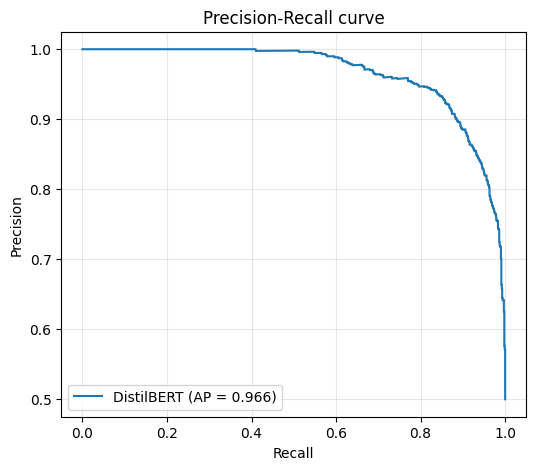

In [5]:
precision, recall, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"DistilBERT (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## ROC-AUC

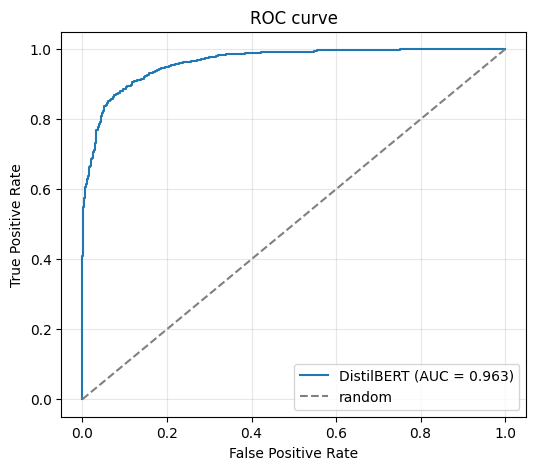

ROC-AUC = 0.9632


In [6]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"DistilBERT (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"ROC-AUC = {roc_auc:.4f}")

## Свои примеры

In [26]:
samples = [
    "Absolutely loved this movie, the acting was brilliant and the story kept me hooked!",
    "It was okay, not great but not awful either — some scenes were really nice.",
    "Bad, very bad!",
    "i dont know. In general good! but sometimes bad. I think its okey",
    "i dont know. In general good! but sometimes bad. I think its fine",
    " u''xx + u''yy = 0.  u(0, y)=u(1, y)=y^2; u(x, 0)=a*x, a > 0; u(x, 1)=a*x+1, a > 0"
]

enc = tokenizer(samples, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**enc)
p = torch.softmax(out.logits, dim=-1).cpu().numpy()

for text, prob in zip(samples, p):
    label = "pos" if prob[1] >= 0.5 else "neg"
    print(f"[{label}] p(pos)={prob[1]:.3f}  |  {text}")

[pos] p(pos)=0.982  |  Absolutely loved this movie, the acting was brilliant and the story kept me hooked!
[pos] p(pos)=0.835  |  It was okay, not great but not awful either — some scenes were really nice.
[neg] p(pos)=0.097  |  Bad, very bad!
[neg] p(pos)=0.232  |  i dont know. In general good! but sometimes bad. I think its okey
[pos] p(pos)=0.529  |  i dont know. In general good! but sometimes bad. I think its fine
[neg] p(pos)=0.411  |   u''xx + u''yy = 0.  u(0, y)=u(1, y)=y^2; u(x, 0)=a*x, a > 0; u(x, 1)=a*x+1, a > 0
